In [1]:
# class RobotabilityGraph that inherits from Graph class 
import os
import sys
for _root in (os.path.abspath(".."), os.path.abspath(".")):
    if os.path.isfile(os.path.join(_root, "src", "utils", "logger.py")):
        if _root not in sys.path:
            sys.path.insert(0, _root)
        break

import osmnx as ox 
import geopandas as gpd 
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt
from src.utils.plotting import setup_matplotlib

from glob import glob 
from tqdm import tqdm 

from shapely import wkt, LineString 

import rasterio
from rasterio.enums import Resampling
from rasterio.plot import show 


from src.utils.logger import setup_logger 

logger = setup_logger('robotability-score')
logger.setLevel("INFO")
if setup_matplotlib(usetex=True):
    logger.info("Matplotlib using LaTeX text.")
else:
    logger.info("Matplotlib LaTeX unavailable (install cm-super to enable); using mathtext.")
logger.info("Modules initialized.")

WGS='EPSG:4326'
PROJ='EPSG:2263'

REGEN_SEGMENTIZATION=True
REGEN_TOPOLOGY=True



2026-08-17 19:40:07 - robotability-score - INFO - Matplotlib using LaTeX text.
2026-08-17 19:40:07 - robotability-score - INFO - Modules initialized.


In [2]:
deployments = { 
    'Elmhurst, Queens': {
        'coords': (40.738536, -73.887267),
        'type': 'high',
    },
    'Sutton Place, Manhattan': {
        'coords': (40.758890, -73.958457),
        'type': 'high',
    },
    'Herald Square, Manhattan': {
        'coords': (40.748422, -73.988275),
        'type': 'low',
    },
    'Jackson Heights, Queens': {
        'coords': (40.747379, -73.889690),
        'type': 'low'
    }
}

deployments = pd.DataFrame(deployments).T
deployments = gpd.GeoDataFrame(deployments, geometry=gpd.points_from_xy(deployments['coords'].apply(lambda x: x[1]), deployments['coords'].apply(lambda x: x[0]))).set_crs(WGS).to_crs(PROJ)

In [3]:
deployments

,coords,type,geometry
"Elmhurst, Queens","(40.738536, -73.887267)",high,POINT (1015490.622 208365.288)
"Sutton Place, Manhattan","(40.75889, -73.958457)",high,POINT (995758.902 215763.531)
"Herald Square, Manhattan","(40.748422, -73.988275)",low,POINT (987498.756 211947.188)
"Jackson Heights, Queens","(40.747379, -73.88969)",low,POINT (1014815.103 211586.217)


In [4]:
# NYC Open Data census-block shapefile is WGS84; scores are in EPSG:2263.
cbs_nyc = gpd.read_file("../feature_processing/data/2020 Census Blocks_20260817/geo_export_52521c75-4166-4b07-b34c-fbeb9c313e4b.shp").to_crs(PROJ)
all_cbs_nyc = cbs_nyc.copy()

In [5]:
all_cbs_nyc

,cb2020,borocode,boroname,ct2020,bctcb2020,geoid,shape_leng,shape_area,geometry
0,1000,1,Manhattan,000100,10001001000,360610001001000,6437.853745,1.202838e+06,"POLYGON ((973172.666 194632.348, 973310.630 19..."
1,1001,1,Manhattan,000100,10001001001,360610001001001,4395.190183,6.401664e+05,"POLYGON ((972081.788 190733.467, 972184.766 19..."
2,2000,1,Manhattan,000201,10002012000,360610002012000,2055.295762,2.633084e+05,"POLYGON ((988422.186 198807.188, 988449.289 19..."
3,1000,1,Manhattan,000202,10002021000,360610002021000,1187.884111,5.711594e+04,"POLYGON ((989804.992 199396.649, 989991.347 19..."
4,2000,1,Manhattan,000202,10002022000,360610002022000,2178.777427,1.573135e+05,"POLYGON ((989275.081 198475.293, 989215.052 19..."
...,...,...,...,...,...,...,...,...,...
37583,1007,3,Brooklyn,066600,30666001007,360470666001007,8801.289040,1.161685e+06,"POLYGON ((1008420.391 152737.417, 1008358.033 ..."
37584,2031,3,Brooklyn,062800,30628002031,360470628002031,6163.944446,4.926251e+05,"POLYGON ((1003488.890 153292.231, 1003317.726 ..."
37585,1003,1,Manhattan,002000,10020001003,360610020001003,2760.472955,3.997260e+05,"POLYGON ((991764.785 201989.606, 991693.289 20..."
37586,1009,4,Queens,017902,40179021009,360810179021009,2708.180314,2.763465e+05,"POLYGON ((1002675.445 210760.412, 1002684.838 ..."


In [6]:
score_nyc = pd.read_csv("../feature_processing/data/processed/score_nyc.csv", engine='pyarrow')

In [7]:
score_nyc

,,point_index,segment_index,geometry,score
0,0,0,0,POINT (915013.8937938461 120812.80296040917),0.050625
1,1,1,0,POINT (915025.562113873 120775.82065290313),0.015013
2,2,2,0,POINT (915037.2304338999 120738.83834539709),-0.005030
3,3,3,0,POINT (915048.8987539269 120701.85603789105),0.109265
4,4,4,0,POINT (915060.5670739537 120664.873730385),0.151599
...,...,...,...,...,...
1902853,1902853,1901079,476396,POINT (1061236.7497256864 218058.7638742144),0.104308
1902854,1902854,1901080,476396,POINT (1061286.530488815 218060.9102225494),0.166141
1902855,1902855,1901081,476396,POINT (1061336.3112519435 218063.05657088436),0.162157
1902856,1902856,1901082,476397,POINT (1060551.1219866222 218340.76721487206),0.211082


In [8]:
score_dataset = pd.read_csv("../feature_processing/data/processed/score_dataset.csv", engine='pyarrow')

In [9]:
score_dataset.columns


Index(['', '5g_technology', '5g_mindown', '5g_minup', '5g_environmnt',
       '5g_h3_res9_id', '4g_technology', '4g_mindown', '4g_minup',
       '4g_environmnt', '4g_h3_res9_id', 'Unnamed: 0', 'width',
       'segment_index', 'geometry', 'point_index', 'ft_above_sea',
       'n_cameras_median', 'Unnamed: 0_street_furniture',
       'width_street_furniture', 'segment_index_street_furniture',
       'geometry_street_furniture', 'bus_stop_count', 'trash_can_count',
       'linknyc_count', 'citybench_count', 'bicycle_parking_shelter_count',
       'bicycle_rack_count', 'tree_count', 'newsstand_count',
       'parking_meter_count', 'hydrant_count', 'street_sign_count',
       'alarm_call_box_count', 'scaffolding_permit_count', 'clutter',
       'ZONEDIST', 'Shape_Leng', 'Shape_Area', 'distance_to_nearest_station',
       'CURBRAMP_count', 'RAISEDCROSSWALK_count', 'boro_cd', 'shape_leng',
       'shape_area', 'cd_code', 'sidewalk_quality', 'POI_the_geom',
       'POI_SEGMENTID', 'POI_COMPLEX

In [10]:
score_dataset[["boro_cd"]]

,boro_cd
0,503.0
1,503.0
2,503.0
3,503.0
4,503.0
...,...
1902853,411.0
1902854,411.0
1902855,411.0
1902856,411.0


<Axes: >

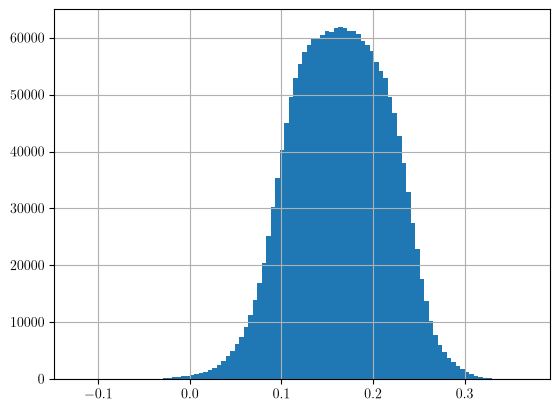

In [11]:
score_nyc['score'].hist(bins=100)

In [12]:
# compute score relative to average in score_rta column 
score_nyc['score_rta'] = score_nyc['score'] / score_nyc['score'].mean()
score_nyc['score_rta'].describe() 

count    1.902858e+06
mean     1.000000e+00
std      3.190605e-01
min     -7.525889e-01
25%      7.656861e-01
50%      1.002359e+00
75%      1.240382e+00
max      2.249595e+00
Name: score_rta, dtype: float64

In [13]:
score_nyc['score_percentile'] = score_nyc['score'].rank(pct=True) * 100
score_nyc['score_percentile'].describe()

count    1.902858e+06
mean     5.000003e+01
std      2.886752e+01
min      5.255253e-05
25%      2.500004e+01
50%      5.000003e+01
75%      7.500001e+01
max      1.000000e+02
Name: score_percentile, dtype: float64

In [14]:
score_nyc = gpd.GeoDataFrame(score_nyc, geometry=wkt.loads(score_nyc['geometry']), crs=PROJ)

In [15]:
score_nyc['score'].describe()

count    1.902858e+06
mean     1.640331e-01
std      5.233648e-02
min     -1.234495e-01
25%      1.255979e-01
50%      1.644201e-01
75%      2.034636e-01
max      3.690080e-01
Name: score, dtype: float64

In [16]:
cbs_nyc

,cb2020,borocode,boroname,ct2020,bctcb2020,geoid,shape_leng,shape_area,geometry
0,1000,1,Manhattan,000100,10001001000,360610001001000,6437.853745,1.202838e+06,"POLYGON ((973172.666 194632.348, 973310.630 19..."
1,1001,1,Manhattan,000100,10001001001,360610001001001,4395.190183,6.401664e+05,"POLYGON ((972081.788 190733.467, 972184.766 19..."
2,2000,1,Manhattan,000201,10002012000,360610002012000,2055.295762,2.633084e+05,"POLYGON ((988422.186 198807.188, 988449.289 19..."
3,1000,1,Manhattan,000202,10002021000,360610002021000,1187.884111,5.711594e+04,"POLYGON ((989804.992 199396.649, 989991.347 19..."
4,2000,1,Manhattan,000202,10002022000,360610002022000,2178.777427,1.573135e+05,"POLYGON ((989275.081 198475.293, 989215.052 19..."
...,...,...,...,...,...,...,...,...,...
37583,1007,3,Brooklyn,066600,30666001007,360470666001007,8801.289040,1.161685e+06,"POLYGON ((1008420.391 152737.417, 1008358.033 ..."
37584,2031,3,Brooklyn,062800,30628002031,360470628002031,6163.944446,4.926251e+05,"POLYGON ((1003488.890 153292.231, 1003317.726 ..."
37585,1003,1,Manhattan,002000,10020001003,360610020001003,2760.472955,3.997260e+05,"POLYGON ((991764.785 201989.606, 991693.289 20..."
37586,1009,4,Queens,017902,40179021009,360810179021009,2708.180314,2.763465e+05,"POLYGON ((1002675.445 210760.412, 1002684.838 ..."


In [17]:
score_nyc

,,point_index,segment_index,geometry,score,score_rta,score_percentile
0,0,0,0,POINT (915013.894 120812.803),0.050625,0.308630,1.382447
1,1,1,0,POINT (915025.562 120775.821),0.015013,0.091526,0.267019
2,2,2,0,POINT (915037.230 120738.838),-0.005030,-0.030666,0.088971
3,3,3,0,POINT (915048.899 120701.856),0.109265,0.666117,15.630541
4,4,4,0,POINT (915060.567 120664.874),0.151599,0.924198,41.591963
...,...,...,...,...,...,...,...
1902853,1902853,1901079,476396,POINT (1061236.750 218058.764),0.104308,0.635895,13.185850
1902854,1902854,1901080,476396,POINT (1061286.530 218060.910),0.166141,1.012848,51.141546
1902855,1902855,1901081,476396,POINT (1061336.311 218063.057),0.162157,0.988561,48.506615
1902856,1902856,1901082,476397,POINT (1060551.122 218340.767),0.211082,1.286826,79.458110


In [18]:
# Spatial join: attach each scored sidewalk point to the census block it falls in.
# Both layers must share a CRS; otherwise geopandas warns and every join is NaN.
by_cb = score_nyc.sjoin(cbs_nyc, how='left', predicate='intersects')

In [19]:
by_cb

,,point_index,segment_index,geometry,score,score_rta,score_percentile,index_right,cb2020,borocode,boroname,ct2020,bctcb2020,geoid,shape_leng,shape_area
0,0,0,0,POINT (915013.894 120812.803),0.050625,0.308630,1.382447,23630.0,2010,5,Staten Island,024402,50244022010,360850244022010,13542.930717,4.306959e+06
1,1,1,0,POINT (915025.562 120775.821),0.015013,0.091526,0.267019,23630.0,2010,5,Staten Island,024402,50244022010,360850244022010,13542.930717,4.306959e+06
2,2,2,0,POINT (915037.230 120738.838),-0.005030,-0.030666,0.088971,23630.0,2010,5,Staten Island,024402,50244022010,360850244022010,13542.930717,4.306959e+06
3,3,3,0,POINT (915048.899 120701.856),0.109265,0.666117,15.630541,23630.0,2010,5,Staten Island,024402,50244022010,360850244022010,13542.930717,4.306959e+06
4,4,4,0,POINT (915060.567 120664.874),0.151599,0.924198,41.591963,23630.0,2010,5,Staten Island,024402,50244022010,360850244022010,13542.930717,4.306959e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1902853,1902853,1901079,476396,POINT (1061236.750 218058.764),0.104308,0.635895,13.185850,18381.0,3010,4,Queens,150702,41507023010,360811507023010,1819.835852,1.056141e+05
1902854,1902854,1901080,476396,POINT (1061286.530 218060.910),0.166141,1.012848,51.141546,18381.0,3010,4,Queens,150702,41507023010,360811507023010,1819.835852,1.056141e+05
1902855,1902855,1901081,476396,POINT (1061336.311 218063.057),0.162157,0.988561,48.506615,18381.0,3010,4,Queens,150702,41507023010,360811507023010,1819.835852,1.056141e+05
1902856,1902856,1901082,476397,POINT (1060551.122 218340.767),0.211082,1.286826,79.458110,17538.0,3002,4,Queens,150702,41507023002,360811507023002,3522.353835,4.143436e+05


In [20]:
# score_by_cb = by_cb.groupby('BCTCB2020').agg({'score':'mean', 'score_rta':'mean', 'score_percentile': 'mean'}).reset_index()
score_by_cb = by_cb.groupby('bctcb2020').agg({'score':'mean', 'score_rta':'mean', 'score_percentile': 'mean'}).reset_index()


In [21]:
score_by_cb

,bctcb2020,score,score_rta,score_percentile
0,10001001000,0.054222,0.330558,5.964302
1,10001001001,0.110775,0.675320,22.637864
2,10002011000,0.167957,1.023920,52.129303
3,10002011001,0.174436,1.063417,55.540907
4,10002012000,0.168682,1.028342,51.907508
...,...,...,...,...
35964,50323001021,0.214766,1.309287,76.509221
35965,50323001022,0.217805,1.327810,76.436903
35966,50323001023,0.225065,1.372068,83.863647
35967,50323001024,0.225340,1.373747,80.202657


In [22]:
score_by_cb['score'].max() / score_by_cb['score'].min()

-12.456226887496975

In [23]:
# Left join so blocks with no sidewalk points keep their geometry (inner merge
# of an empty score_by_cb would wipe cbs_nyc and crash the choropleth).
cbs_nyc = cbs_nyc.merge(score_by_cb, on='bctcb2020', how='left', suffixes=('', '_mean'))

/tmp/ipykernel_154742/835152270.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  cbar.set_xticklabels([str(int(tick)) + r'\textsuperscript{th}' for tick in cbar.get_xticks()])


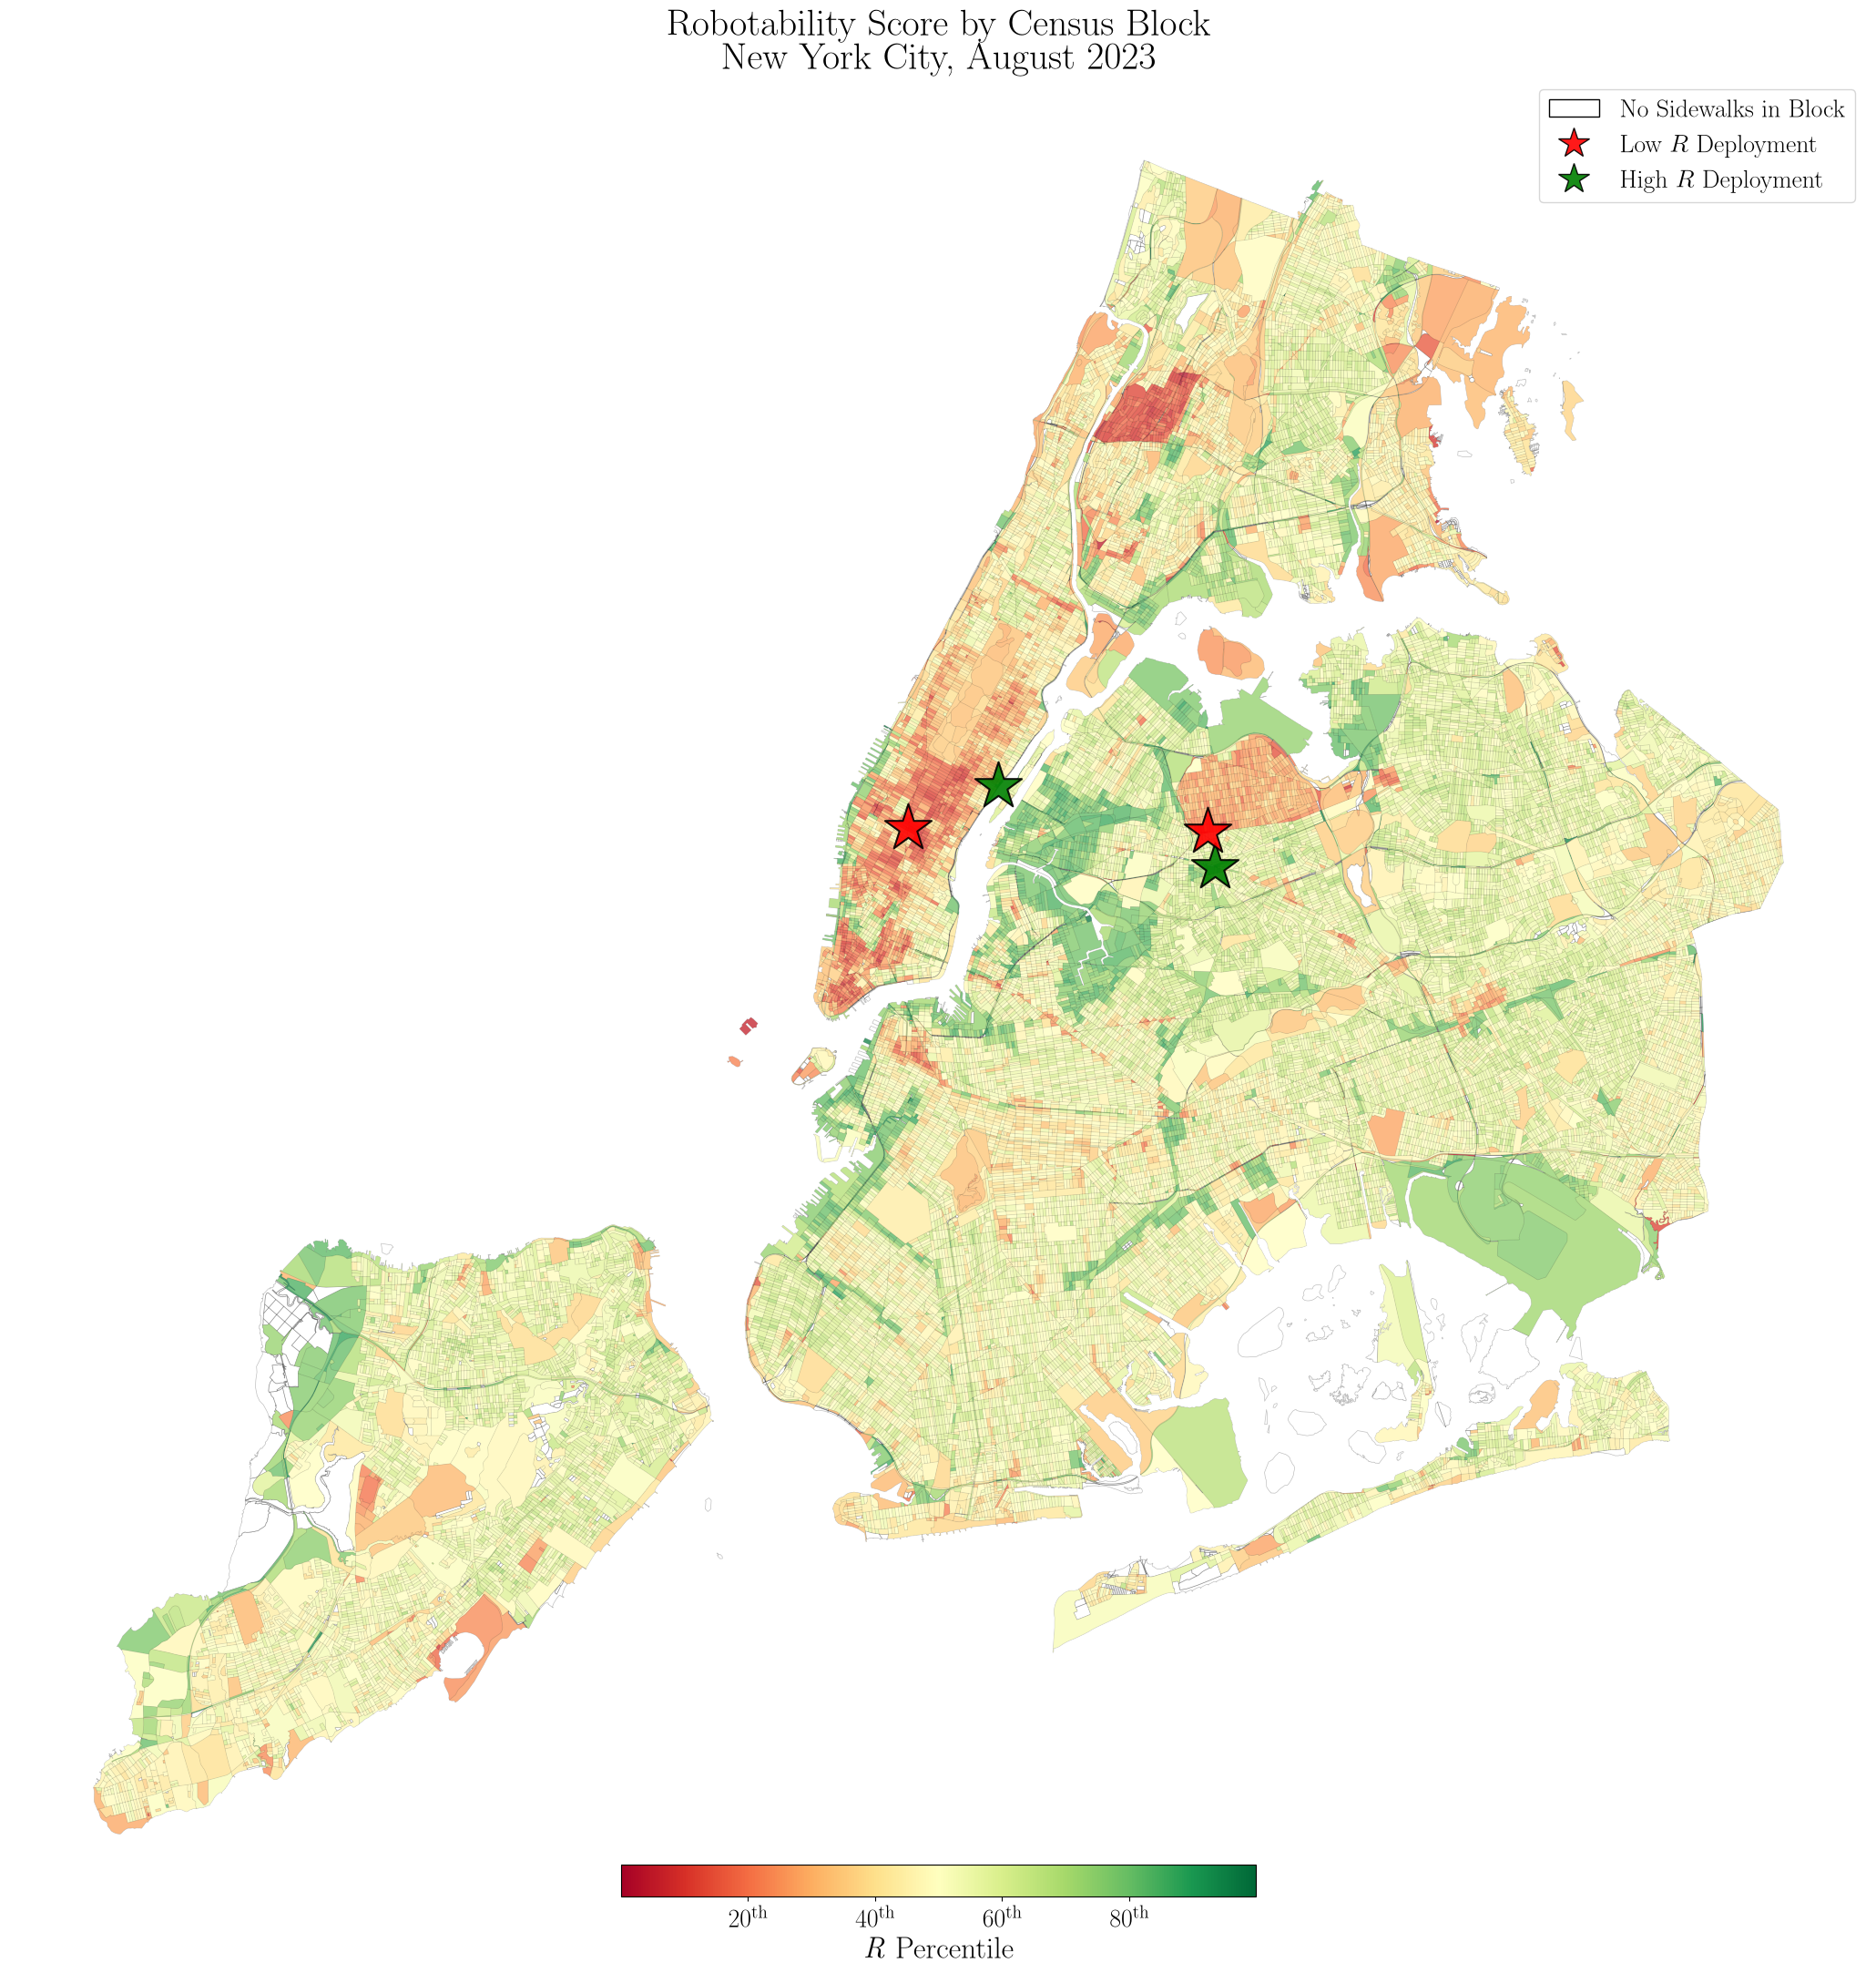

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(30, 30))

# get coolwarm colormap and inverse it 
cmap = plt.get_cmap('RdYlGn')
#cmap = cmap.reversed()

all_cbs_nyc.boundary.plot(ax=ax, color='black', linewidth=0.5, alpha=0.25, zorder=0)
cbs_nyc.plot(column='score_percentile', ax=ax, legend=True, cmap=cmap, legend_kwds={'orientation': "horizontal", 'shrink': 0.3, 'pad': -0.025}, zorder=1, alpha=0.75),

# set colorbar font size 
cbar = ax.get_figure().get_axes()[1]
cbar.tick_params(labelsize=20)
# set label font size on colorbar 
cbar.set_xlabel(r"\textit{R} Percentile", fontsize=24)

# add 'th' to the end of the percentile for each tick label 
cbar.set_xticklabels([str(int(tick)) + r'\textsuperscript{th}' for tick in cbar.get_xticks()])

plt.title("Robotability Score by Census Block" "\n" "New York City, August 2023", fontsize=30)


from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# add red and green markers for high and low deployements
for i, row in deployments.iterrows():
    ax.scatter(row['geometry'].x, row['geometry'].y, 
              color='red' if row['type'] == 'low' else 'green', 
              s=1500, marker='*', zorder=2, 
              edgecolor='black', linewidth=1.5, alpha=0.9)

# Create legend elements with matching markers
legend_elements = [
    Patch(facecolor='white', edgecolor='black', label='No Sidewalks in Block'),
    Line2D([0], [0], marker='*', color='red', label=r'Low $R$ Deployment',
           markerfacecolor='red', markersize=25, linestyle='none',
           markeredgecolor='black', markeredgewidth=1, alpha=0.9),
    Line2D([0], [0], marker='*', color='green', label=r'High $R$ Deployment',
           markerfacecolor='green', markersize=25, linestyle='none',
           markeredgecolor='black', markeredgewidth=1, alpha=0.9)
]

ax.legend(handles=legend_elements, loc='upper right', fontsize=20)


ax.set_axis_off()


plt.savefig("../chi24_roving_whiteboards/figures/robotability_score_by_cb.pdf", dpi=300, bbox_inches='tight')